# Data setup

In [223]:
# Importing packages
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from imblearn.over_sampling import SMOTE
from sklearn.metrics import precision_recall_curve
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
import math
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_graphviz, export_text, DecisionTreeRegressor
from IPython.display import Image
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import roc_curve, auc, average_precision_score, precision_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, f1_score, confusion_matrix, r2_score
from sklearn.metrics import recall_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [224]:
file_path = "/content/drive/MyDrive/project 6912/Bankrupt data.csv"
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()
print(df.shape)
print(df.columns)

(6819, 96)
Index(['Bankrupt?', 'ROA(C) before interest and depreciation before interest',
       'ROA(A) before interest and % after tax',
       'ROA(B) before interest and depreciation after tax',
       'Operating Gross Margin', 'Realized Sales Gross Margin',
       'Operating Profit Rate', 'Pre-tax net Interest Rate',
       'After-tax net Interest Rate',
       'Non-industry income and expenditure/revenue',
       'Continuous interest rate (after tax)', 'Operating Expense Rate',
       'Research and development expense rate', 'Cash flow rate',
       'Interest-bearing debt interest rate', 'Tax rate (A)',
       'Net Value Per Share (B)', 'Net Value Per Share (A)',
       'Net Value Per Share (C)', 'Persistent EPS in the Last Four Seasons',
       'Cash Flow Per Share', 'Revenue Per Share (Yuan ¥)',
       'Operating Profit Per Share (Yuan ¥)',
       'Per Share Net profit before tax (Yuan ¥)',
       'Realized Sales Gross Profit Growth Rate',
       'Operating Profit Growth Rate',

In [225]:
df_train = df[:3000]
df_test = df[3000:5000]
df_vals = df[5000:]

# remove target column to create feature only dataset

X_train, X_test, X_vals = df_train.drop('Bankrupt?',axis=1), df_test.drop('Bankrupt?',axis=1), df_vals.drop('Bankrupt?',axis=1)
# store target column
y_train, y_test, y_vals = df_train['Bankrupt?'], df_test['Bankrupt?'], df_vals['Bankrupt?']
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)
print(X_vals.shape, y_vals.shape)

(3000, 95) (3000,)
(2000, 95) (2000,)
(1819, 95) (1819,)


# Logistic regression

In [226]:
from imblearn.over_sampling import RandomOverSampler

# Separate features (X) and target variable (y) for the training data
X_train = df_train.drop('Bankrupt?', axis=1)
y_train = df_train['Bankrupt?']

# Initialize RandomOverSampler
oversampler = RandomOverSampler(sampling_strategy=0.5, random_state=0)

# Resample the training data
X_train_resampled, y_train_resampled = oversampler.fit_resample(X_train, y_train)

# Create a new balanced training DataFrame
train_data_resampled = pd.DataFrame(X_train_resampled, columns=X_train.columns)
train_data_resampled['Bankrupt?'] = y_train_resampled

In [227]:
# Separate features and target variable
X_train = df_train.drop('Bankrupt?', axis=1)
y_train = df_train['Bankrupt?']

# Initialize SMOTE with the desired sampling strategy
smote = SMOTE(sampling_strategy=0.5, random_state=0)

# Apply SMOTE to oversample the minority class
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [228]:
# Separate features and target variable
X_test = df_test.drop('Bankrupt?', axis=1)
y_test = df_test['Bankrupt?']

# Initialize SMOTE with the desired sampling strategy
smote = SMOTE(sampling_strategy=0.5, random_state=0)

# Apply SMOTE to oversample the minority class
X_test_resampled, y_test_resampled = smote.fit_resample(X_test, y_test)

In [229]:
from sklearn.preprocessing import StandardScaler

standardscalar = StandardScaler()

scaled_X = standardscalar.fit_transform(X_train)
scaled_X_test = standardscalar.transform(X_test_resampled)

In [230]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the logistic regression model
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_resampled, y_train_resampled)

LogisticRegression(max_iter=1000)

In [231]:
print(logreg.coef_)

[[-1.54196210e-12 -1.75136092e-12 -1.57876321e-12  9.09279521e-14
   9.34327858e-14  4.88064180e-13  3.84671724e-13  3.93682840e-13
   1.37188300e-13  3.78170348e-13 -3.73556086e-11 -4.25752338e-11
   7.12024621e-14 -4.56778999e-09 -2.26555206e-12 -4.62354870e-13
  -4.68171073e-13 -4.65930581e-13 -7.51582761e-13  7.19054699e-15
  -2.71637434e-06 -3.65247551e-13 -6.93619465e-13  9.12801567e-15
   3.76026159e-13  2.32450012e-13  2.33532420e-13  9.81858309e-14
  -7.31199499e-11  5.43063247e-06  1.09210788e-13  9.53218173e-14
  -5.61667829e-06 -6.80116671e-11  2.80370278e-13  2.87966685e-11
   1.77118308e-12 -1.28514541e-12 -3.61555037e-14  7.03794840e-13
   2.22691581e-13 -3.60261836e-13 -6.60807559e-13  3.60219030e-13
  -5.61530390e-13 -1.08613145e-05 -6.83727100e-06 -1.99214403e-11
   7.79151683e-11  1.93131016e-13  5.91341035e-06 -1.91672180e-13
  -1.48709444e-06 -8.07693163e-13 -3.59425850e-13  3.50068210e-13
  -9.65253486e-13 -3.18015862e-06  2.44100372e-10  1.42271023e-12
  -1.33502

In [232]:
logreg2 = LogisticRegression(max_iter=1000, penalty='l1', solver='liblinear', C = 0.01, class_weight = 'balanced')
logreg2.fit(scaled_X, y_train)

LogisticRegression(C=0.01, class_weight='balanced', max_iter=1000, penalty='l1',
                   solver='liblinear')

In [233]:
print(logreg2.coef_)

[[-0.13579275  0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.         -0.0088083   0.          0.
  -0.85130866  0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.35816729 -0.42964001  0.          0.          0.          0.
   0.          0.         -0.15133233  0.          0.          0.
   0.06266127  0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.         -0.0680314   0.          0.00261887  0.          0.
   0.          0.         -0.11318211  0.          0.          0.
   0.         -0.01208188  0.          0.          0.          0.
   0.     

In [234]:
# prompt: Find the name of the features with non zero coefficients in logreg2

import numpy as np

# Get the coefficients of the logistic regression model
coefficients = logreg2.coef_

# Find the indices where the coefficients are non-zero
non_zero_indices = np.where(coefficients != 0)[1]

# Get the feature names corresponding to the non-zero coefficients
feature_names = X_train.columns[non_zero_indices]

# Print the names of the features with non-zero coefficients
feature_names


Index(['ROA(C) before interest and depreciation before interest',
       'Net Value Per Share (B)', 'Persistent EPS in the Last Four Seasons',
       'Debt ratio %', 'Net worth/Assets', 'Total Asset Turnover',
       'Fixed Assets Turnover Frequency', 'Cash Turnover Rate',
       'Fixed Assets to Assets', 'Cash Flow to Liability',
       'Net Income to Total Assets'],
      dtype='object')

In [235]:
from sklearn.metrics import confusion_matrix, classification_report

# Predict on training set
y_train_pred = logreg.predict(X_train_resampled)

# Evaluate on training set
print("\nTraining Set (Resampled):")
print("Confusion Matrix:\n", confusion_matrix(y_train_resampled, y_train_pred))
print("Classification Report:\n", classification_report(y_train_resampled, y_train_pred))


# Prepare data for evaluation
X_val = df_vals.drop('Bankrupt?', axis=1)
y_val = df_vals['Bankrupt?']
X_test = df_test.drop('Bankrupt?', axis=1)
y_test = df_test['Bankrupt?']

# Predict on validation set
y_val_pred = logreg.predict(X_val)

# Evaluate on validation set
print("Validation Set:")
print("Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred))
print("Classification Report:\n", classification_report(y_val, y_val_pred))

# Predict on test set
y_test_pred = logreg.predict(X_test)

# Evaluate on test set
print("\nTest Set:")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("Classification Report:\n", classification_report(y_test, y_test_pred))


Training Set (Resampled):
Confusion Matrix:
 [[2687  148]
 [1258  159]]
Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.95      0.79      2835
           1       0.52      0.11      0.18      1417

    accuracy                           0.67      4252
   macro avg       0.60      0.53      0.49      4252
weighted avg       0.63      0.67      0.59      4252

Validation Set:
Confusion Matrix:
 [[1727   64]
 [  24    4]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.96      0.98      1791
           1       0.06      0.14      0.08        28

    accuracy                           0.95      1819
   macro avg       0.52      0.55      0.53      1819
weighted avg       0.97      0.95      0.96      1819


Test Set:
Confusion Matrix:
 [[1858  115]
 [  27    0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99    

In [236]:
from sklearn.metrics import confusion_matrix, classification_report

# Predict on training set
y_train_pred = logreg2.predict(X_train_resampled)

# Evaluate on training set
print("\nTraining Set (Resampled):")
print("Confusion Matrix:\n", confusion_matrix(y_train_resampled, y_train_pred))
print("Classification Report:\n", classification_report(y_train_resampled, y_train_pred))


# Prepare data for evaluation
X_val = df_vals.drop('Bankrupt?', axis=1)
y_val = df_vals['Bankrupt?']
X_test = df_test.drop('Bankrupt?', axis=1)
y_test = df_test['Bankrupt?']

# Predict on validation set
y_val_pred = logreg2.predict(X_val)

# Evaluate on validation set
print("Validation Set:")
print("Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred))
print("Classification Report:\n", classification_report(y_val, y_val_pred))

# Predict on test set
y_test_pred = logreg2.predict(X_test)

# Evaluate on test set
print("\nTest Set:")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("Classification Report:\n", classification_report(y_test, y_test_pred))


Training Set (Resampled):
Confusion Matrix:
 [[2339  496]
 [ 956  461]]
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.83      0.76      2835
           1       0.48      0.33      0.39      1417

    accuracy                           0.66      4252
   macro avg       0.60      0.58      0.58      4252
weighted avg       0.63      0.66      0.64      4252

Validation Set:
Confusion Matrix:
 [[1678  113]
 [  24    4]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.94      0.96      1791
           1       0.03      0.14      0.06        28

    accuracy                           0.92      1819
   macro avg       0.51      0.54      0.51      1819
weighted avg       0.97      0.92      0.95      1819


Test Set:
Confusion Matrix:
 [[1639  334]
 [  20    7]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99    

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


[0.28801569 0.40228638 0.4308971  ... 0.31331192 0.37754658 0.33312961]
AUC random predictions = 0.5
AUC predictions from logistic regression model = 0.5041827346664762
AUC predictions from penalized logistic regression model = 0.9441471014887596


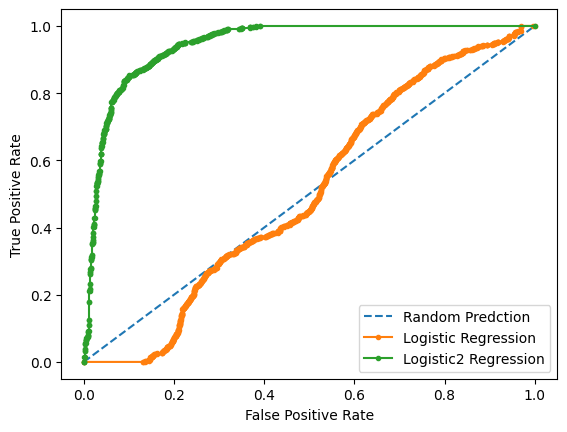

In [237]:

# Calculate the receiver operating curve and the AUC measure

lr_prob=logreg.predict_proba(X_test_resampled)
lr_prob2=logreg2.predict_proba(scaled_X_test)
lr_prob=lr_prob[:, 1]
lr_prob2 = lr_prob2[:, 1]
print(lr_prob)
ns_prob=[0 for _ in range(len(y_test_resampled))]
ns_auc=roc_auc_score(y_test_resampled, ns_prob)
lr_auc=roc_auc_score(y_test_resampled,lr_prob)
ns_prob2=[0 for _ in range(len(y_test_resampled))]
ns_auc2=roc_auc_score(y_test_resampled, ns_prob2)
lr_auc2=roc_auc_score(y_test_resampled,lr_prob2)
print("AUC random predictions =", ns_auc)
print("AUC predictions from logistic regression model =", lr_auc)
print("AUC predictions from penalized logistic regression model =", lr_auc2)
ns_fpr,ns_tpr,_=roc_curve(y_test_resampled,ns_prob)
lr_fpr,lr_tpr,_=roc_curve(y_test_resampled,lr_prob)
ns_fpr2,ns_tpr2,_=roc_curve(y_test_resampled,ns_prob2)
lr_fpr2,lr_tpr2,_=roc_curve(y_test_resampled,lr_prob2)

plt.plot(ns_fpr,ns_tpr,linestyle='--',label='Random Predction')
plt.plot(lr_fpr,lr_tpr,marker='.',label='Logistic Regression')
plt.plot(lr_fpr2,lr_tpr2,marker='.',label='Logistic2 Regression')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

#KNN

In [238]:
# Defining features and targets
X = df.drop(columns=['Bankrupt?'])
y = df['Bankrupt?']
# Scaling dataset using Standard Scaler
X_scaled = StandardScaler().fit_transform(X)

In [239]:
# Using PCA to reduce the dimensionality and find the number of features with 90% and 95% variance
from sklearn.decomposition import PCA

pca_90 = PCA(n_components=0.90)
X_pca_90 = pca_90.fit_transform(X_scaled)
print(pca_90.n_components_)

pca_95 = PCA(n_components=0.95)
X_pca_95 = pca_95.fit_transform(X_scaled)
print(pca_95.n_components_)

45
53


In [240]:
# Calculating mutual information
mi_selector = SelectKBest(score_func=mutual_info_classif, k='all')
mi_selector.fit(X_scaled, y)
mi_scores = pd.Series(mi_selector.scores_, index=X.columns).dropna().sort_values(ascending=False)

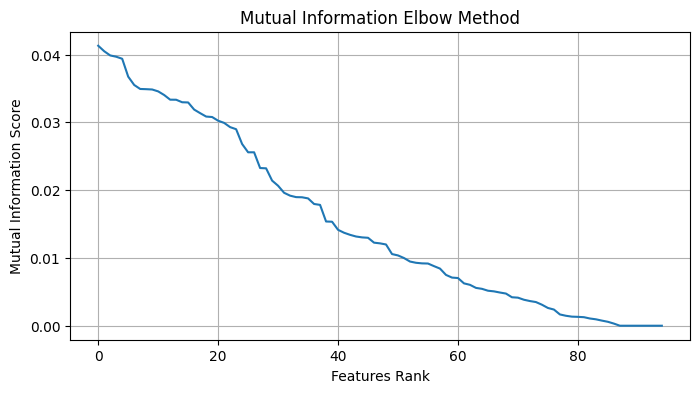

In [241]:
# Plotting mutual information with different numbers of feature to find elbow
plt.figure(figsize=(8, 4))
mi_scores.reset_index(drop=True).plot()
plt.title("Mutual Information Elbow Method")
plt.xlabel("Features Rank")
plt.ylabel("Mutual Information Score")
plt.grid(True)
plt.show()

In [242]:
# Showing the most important features and their mutual information score
for n in [5, 10, 13, 20, 45, 53]:
    print(f"\n Top {n} features that were identified by mutual information:")
    top_n = mi_scores.head(n)
    for feature, score in top_n.items():
        print(f"{feature}: {score:.4f}")


 Top 5 features that were identified by mutual information:
Persistent EPS in the Last Four Seasons: 0.0413
Net Income to Stockholder's Equity: 0.0405
Net profit before tax/Paid-in capital: 0.0399
Per Share Net profit before tax (Yuan ¥): 0.0397
Borrowing dependency: 0.0394

 Top 10 features that were identified by mutual information:
Persistent EPS in the Last Four Seasons: 0.0413
Net Income to Stockholder's Equity: 0.0405
Net profit before tax/Paid-in capital: 0.0399
Per Share Net profit before tax (Yuan ¥): 0.0397
Borrowing dependency: 0.0394
Net Income to Total Assets: 0.0367
ROA(A) before interest and % after tax: 0.0355
Debt ratio %: 0.0349
Net worth/Assets: 0.0349
Continuous interest rate (after tax): 0.0348

 Top 13 features that were identified by mutual information:
Persistent EPS in the Last Four Seasons: 0.0413
Net Income to Stockholder's Equity: 0.0405
Net profit before tax/Paid-in capital: 0.0399
Per Share Net profit before tax (Yuan ¥): 0.0397
Borrowing dependency: 0.03

In [243]:
# Creating a top features sets and store the storing results
results = []
top_n_list = [5, 10, 13, 20, 45, 53]

KNN Model with Top 5 features:
The best K is 2
              precision    recall  f1-score   support

           0     0.9952    0.9493    0.9717      1973
           1     0.1525    0.6667    0.2483        27

    accuracy                         0.9455      2000
   macro avg     0.5739    0.8080    0.6100      2000
weighted avg     0.9838    0.9455    0.9620      2000



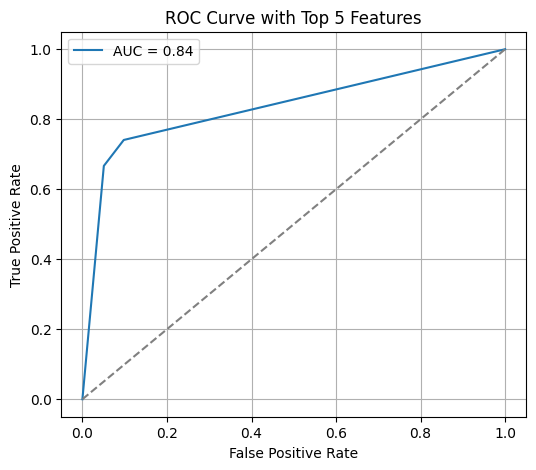

KNN Model with Top 10 features:
The best K is 2
              precision    recall  f1-score   support

           0     0.9952    0.9493    0.9717      1973
           1     0.1525    0.6667    0.2483        27

    accuracy                         0.9455      2000
   macro avg     0.5739    0.8080    0.6100      2000
weighted avg     0.9838    0.9455    0.9620      2000



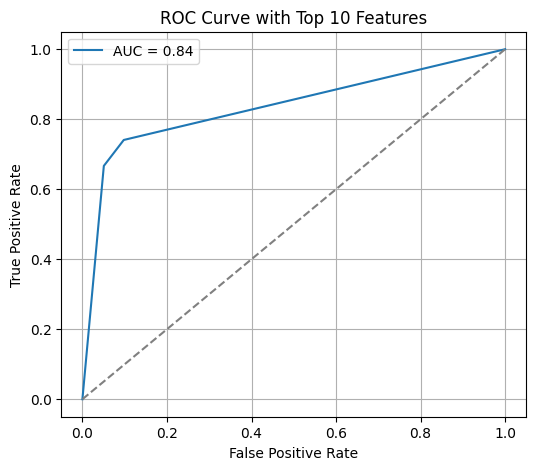

KNN Model with Top 13 features:
The best K is 2
              precision    recall  f1-score   support

           0     0.9952    0.9493    0.9717      1973
           1     0.1525    0.6667    0.2483        27

    accuracy                         0.9455      2000
   macro avg     0.5739    0.8080    0.6100      2000
weighted avg     0.9838    0.9455    0.9620      2000



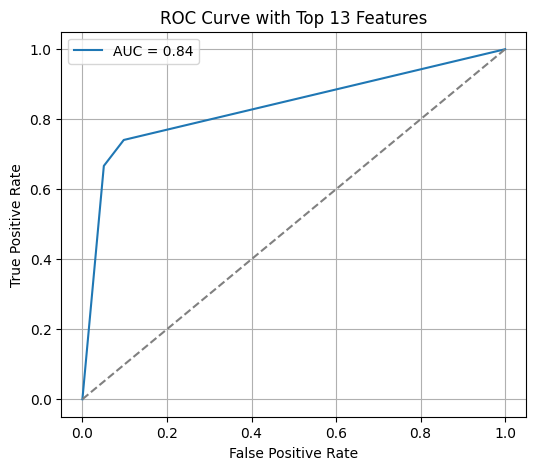

KNN Model with Top 20 features:
The best K is 2
              precision    recall  f1-score   support

           0     0.9952    0.9493    0.9717      1973
           1     0.1525    0.6667    0.2483        27

    accuracy                         0.9455      2000
   macro avg     0.5739    0.8080    0.6100      2000
weighted avg     0.9838    0.9455    0.9620      2000



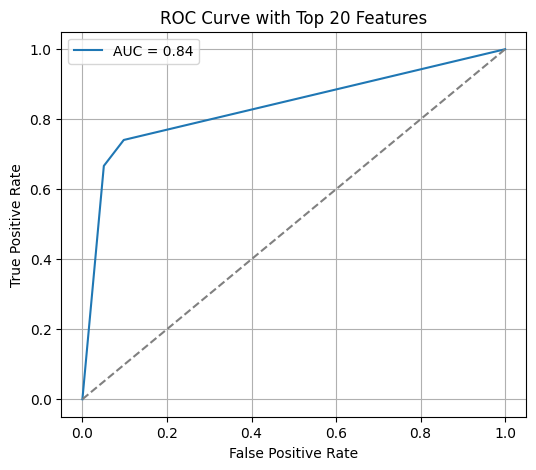

KNN Model with Top 45 features:
The best K is 2
              precision    recall  f1-score   support

           0     0.9952    0.9493    0.9717      1973
           1     0.1525    0.6667    0.2483        27

    accuracy                         0.9455      2000
   macro avg     0.5739    0.8080    0.6100      2000
weighted avg     0.9838    0.9455    0.9620      2000



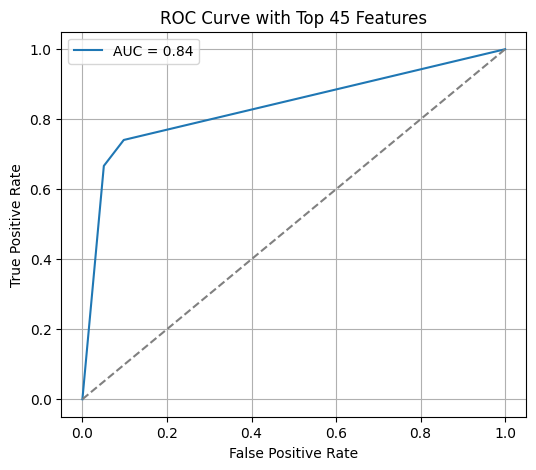

KNN Model with Top 53 features:
The best K is 2
              precision    recall  f1-score   support

           0     0.9952    0.9493    0.9717      1973
           1     0.1525    0.6667    0.2483        27

    accuracy                         0.9455      2000
   macro avg     0.5739    0.8080    0.6100      2000
weighted avg     0.9838    0.9455    0.9620      2000



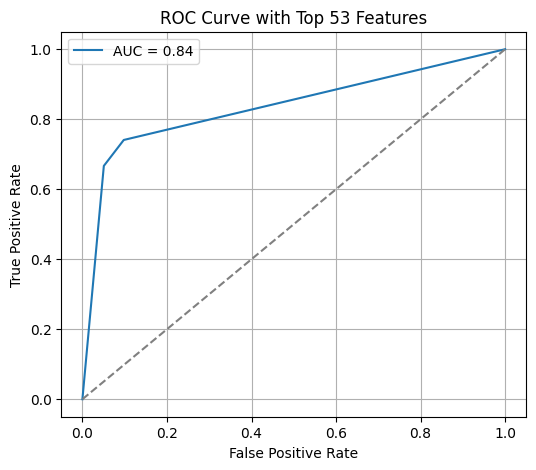

In [244]:
df_train = df[:3000]
df_test = df[3000:5000]
df_vals = df[5000:]

# remove target column to create feature only dataset

X_train, X_test, X_val = df_train.drop('Bankrupt?',axis=1), df_test.drop('Bankrupt?',axis=1), df_vals.drop('Bankrupt?',axis=1)
# store target column
y_train, y_test, y_val = df_train['Bankrupt?'], df_test['Bankrupt?'], df_vals['Bankrupt?']

# Setting up for loop to show each features
for n in top_n_list:
    print(f"KNN Model with Top {n} features:")

    # Selecting each top feature
    selected_features = mi_scores.head(n).index.tolist()

    # Obtaining features
    X_sel = X[selected_features]

    # Slicing dataset to 60% training set, 20% validation set, and 20% test set
   # X_temp, X_test, y_temp, y_test = train_test_split(X_sel, y, test_size=0.2, stratify=y, random_state=42)
   # X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42)

    # Scaling dataset for KNN model
    scaler = StandardScaler()
    X_train_std = scaler.fit_transform(X_train)
    X_val_std = scaler.transform(X_val)
    X_test_std = scaler.transform(X_test)

    # Fitting training set to smote to balance the data
    sm = SMOTE(random_state=42)
    X_train_bal, y_train_bal = sm.fit_resample(X_train_std, y_train)

    # Checking the best K using cross validation
    best_k = 1
    best_f1 = 0
    for k_try in range(1, 21):
        knn_try = KNeighborsClassifier(n_neighbors=k_try)
        f1 = cross_val_score(knn_try, X_train_bal, y_train_bal, cv=5, scoring='f1').mean()
        if f1 > best_f1:
            best_k = k_try
            best_f1 = f1

    print(f"The best K is {best_k}")

    # Fitting balanced dataset to KNN classifier
    knn = KNeighborsClassifier(n_neighbors=best_k)
    knn.fit(X_train_bal, y_train_bal)

    # Using the test set and calculauting AUC
    y_pred = knn.predict(X_test_std)
    y_proba = knn.predict_proba(X_test_std)[:, 1]

    fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr_knn, tpr_knn)

    print(classification_report(y_test, y_pred, digits=4))

    # Plotting ROC AUC Curve
    plt.figure(figsize=(6, 5))
    plt.plot(fpr_knn, tpr_knn, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve with Top {n} Features")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Storing all results
    results.append({
        "Top K Features": n,
        "Best K": best_k,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "AUC": roc_auc
    })

# Decision tree

In [245]:
df_train = df[:3000]
df_test = df[3000:5000]
df_vals = df[5000:]

# remove target column to create feature only dataset

X_train, X_test, X_vals = df_train.drop('Bankrupt?',axis=1), df_test.drop('Bankrupt?',axis=1), df_vals.drop('Bankrupt?',axis=1)
# store target column
y_train, y_test, y_vals = df_train['Bankrupt?'], df_test['Bankrupt?'], df_vals['Bankrupt?']

(3000, 95) (3000,)
(2000, 95) (2000,)
(1819, 95) (1819,)


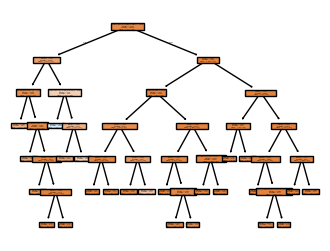

In [246]:
# Define a list of feature column
# We should delete some of the feature here:
selected_features = [
  'Net Value Growth Rate',
  'Net Income to Stockholder\'s Equity',
  'Persistent EPS in the Last Four Seasons',
  'Borrowing dependency',
  'Net profit before tax/Paid-in capital',
  'Non-industry income and expenditure/revenue',
  'Interest Expense Ratio',
  'Net Income to Total Assets',
  'Degree of Financial Leverage (DFL)',
  'Cash/Total Assets',
  'Net Value Per Share (B)',
  ''
]

# Select only these feature columns
#X_train = X_train[selected_features]
#X_test = X_test[selected_features]
#X_vals = X_vals[selected_features]
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Verify the shape
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)
print(X_vals.shape, y_vals.shape)

clf = DecisionTreeClassifier(criterion='entropy', max_depth=10, max_features = 'sqrt', min_samples_leaf=50, min_samples_split=2, random_state=40)
clf = clf.fit(X_train,y_train)
fig, ax = plt.subplots(figsize=(4, 3))
plot_tree(clf, filled=True, feature_names=X_train.columns, proportion=True)
plt.show()

(2000,)
[[1948   25]
 [  22    5]]


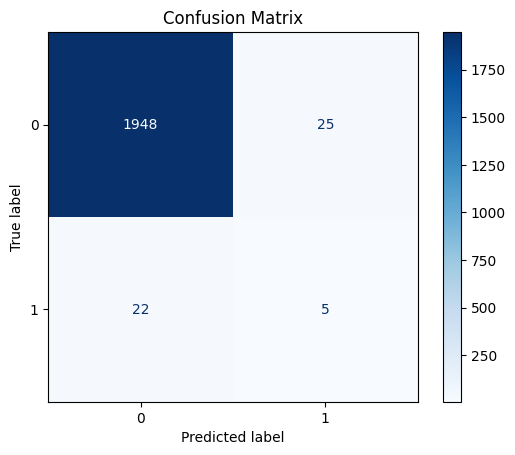

In [247]:

# Confusion Matrix
predictions2 = clf.predict(X_test)
cm3 = confusion_matrix(y_test, predictions2)
print(y_test.shape)
print(cm3)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [248]:
THRESHOLD = [.75, .80, .85]
results = pd.DataFrame(columns=["THRESHOLD", "accuracy", "true pos rate", "true neg rate", "false pos rate", "precision", "f-score"]) # df to store results
results['THRESHOLD'] = THRESHOLD                                                                           # threshold column
n_test = len(y_test)
Q = clf.predict_proba(X_test)[:,1]

j = 0
for i in THRESHOLD:                                                                                        # iterate over each threshold
                                                                         # fit data to model
    preds = np.where(Q>i, 1, 0)                                       # if prob > threshold, predict 1

    cm = (confusion_matrix(y_test, preds,labels=[1, 0], sample_weight=None)/n_test)*100
    # confusion matrix (in percentage)

    print('Confusion matrix for threshold =',i)
    print(cm)
    print(' ')

    TP = cm[0][0]                                                                                          # True Positives
    FN = cm[0][1]                                                                                          # False Positives
    FP = cm[1][0]                                                                                          # True Negatives
    TN = cm[1][1]                                                                                          # False Negatives

    results.iloc[j,1] = accuracy_score(y_test, preds)
    results.iloc[j,2] = recall_score(y_test, preds)
    results.iloc[j,3] = TN/(FP+TN)                                                                         # True negative rate
    results.iloc[j,4] = FP/(FP+TN)                                                                         # False positive rate
    results.iloc[j,5] = precision_score(y_test, preds)
    results.iloc[j,6] = f1_score(y_test, preds)

    j += 1

print('ALL METRICS')
print(results.T.to_string(header=False))

Confusion matrix for threshold = 0.75
[[ 0.    1.35]
 [ 0.   98.65]]
 
Confusion matrix for threshold = 0.8
[[ 0.    1.35]
 [ 0.   98.65]]
 
Confusion matrix for threshold = 0.85
[[ 0.    1.35]
 [ 0.   98.65]]
 
ALL METRICS
THRESHOLD         0.75     0.8    0.85
accuracy        0.9865  0.9865  0.9865
true pos rate      0.0     0.0     0.0
true neg rate      1.0     1.0     1.0
false pos rate     0.0     0.0     0.0
precision          0.0     0.0     0.0
f-score            0.0     0.0     0.0


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [249]:
# Compute the ROC curve and AUC
fpr, tpr, _ = roc_curve(y_test, Q)
roc_auc = auc(fpr,tpr)

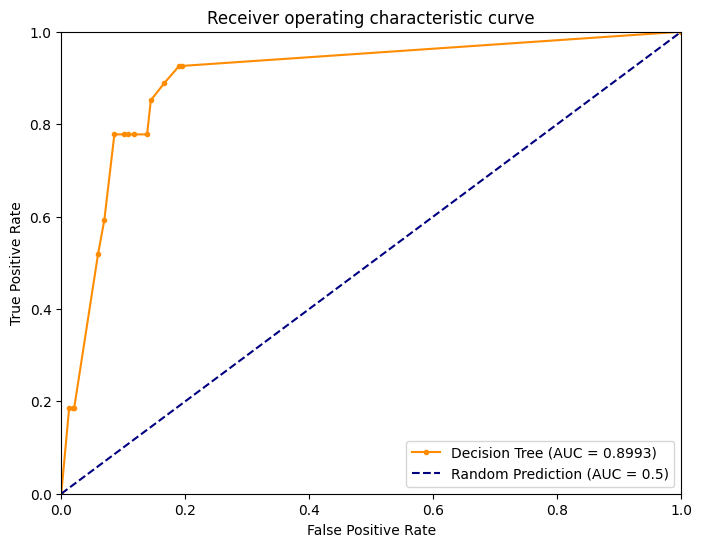

In [250]:
plt.figure(figsize=(8,6))      # format the plot size
lw = 1.5
plt.plot(fpr, tpr, color='darkorange', marker='.',
         lw=lw, label='Decision Tree (AUC = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--',
         label='Random Prediction (AUC = 0.5)' )
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic curve')
plt.legend(loc="lower right")
plt.show()

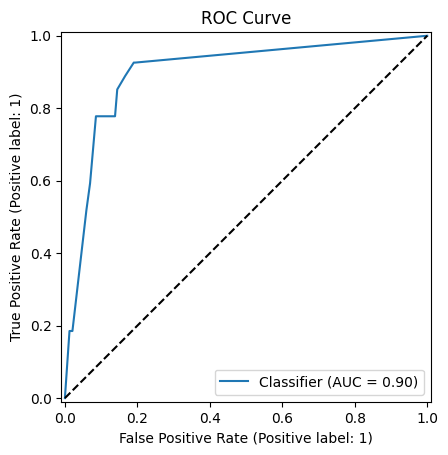

In [251]:
from sklearn.metrics import RocCurveDisplay

y_proba = clf.predict_proba(X_test)[:, 1]
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve')
plt.show()

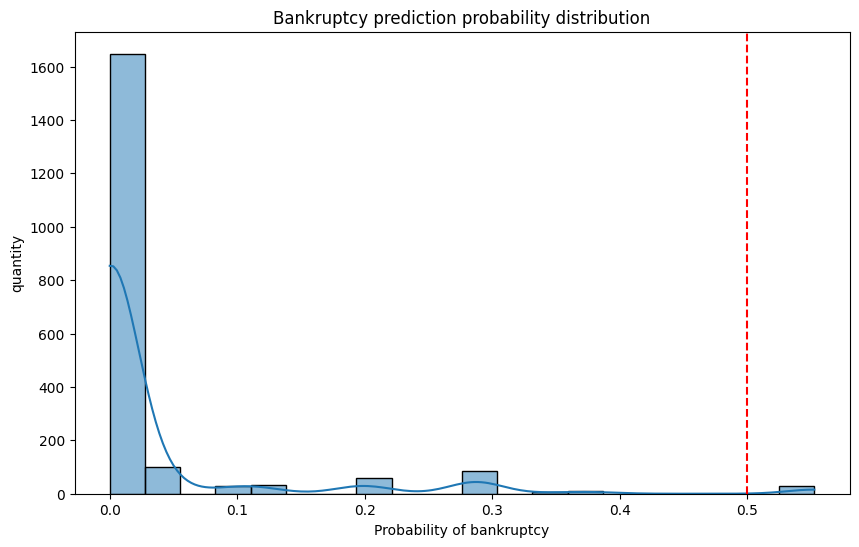

In [252]:
plt.figure(figsize=(10, 6))
sns.histplot(y_proba, bins=20, kde=True)
plt.title('Bankruptcy prediction probability distribution')
plt.xlabel('Probability of bankruptcy')
plt.ylabel('quantity')
plt.axvline(x=0.5, color='r', linestyle='--') # Decision threshold
plt.show()

# Random Forest

In [253]:
# Separating features and target variables
X = df.drop('Bankrupt?', axis=1)
y = df['Bankrupt?']

# Handling missing values ​​(if any)
X = X.fillna(X.mean())

# Standardize the data
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# Split training set and test set
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [254]:
# Create the final model using the best parameters found
rf = RandomForestClassifier(
    max_depth=10,
    min_samples_leaf=4,
    min_samples_split=10,
    n_estimators=100,
    random_state=42
)

# Retrain on all training data (no need to keep validation set)
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=4, min_samples_split=10,
                       random_state=42)

Optimized model evaluation:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1973
           1       0.24      0.15      0.18        27

    accuracy                           0.98      2000
   macro avg       0.61      0.57      0.59      2000
weighted avg       0.98      0.98      0.98      2000


Confusion Matrix:
[[1960   13]
 [  23    4]]


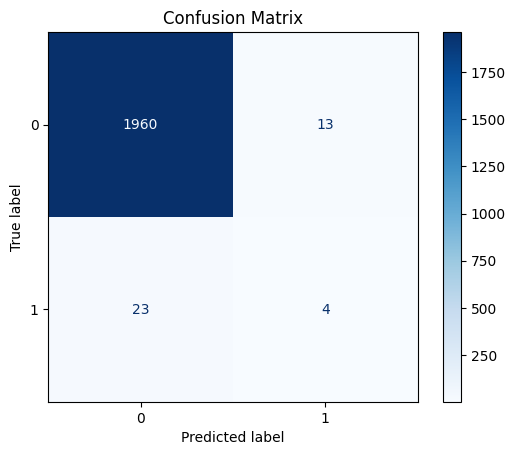

In [255]:
# Prediction test set
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]  # Get bankruptcy probability

print("Optimized model evaluation:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

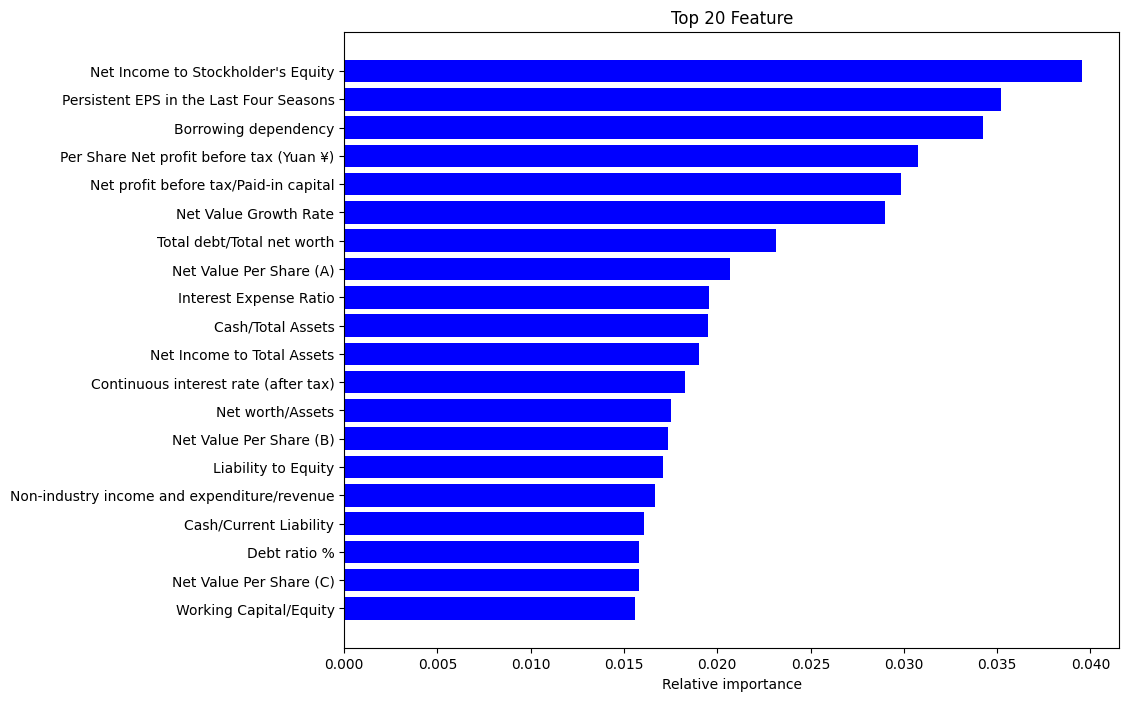

In [256]:
# Get feature importance
importances = rf.feature_importances_
features = X.columns
indices = np.argsort(importances)[-20:]  # Take the 20 most important features

plt.figure(figsize=(10, 8))
plt.title('Top 20 Feature')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative importance')
plt.show()

## ROC and probability distribution

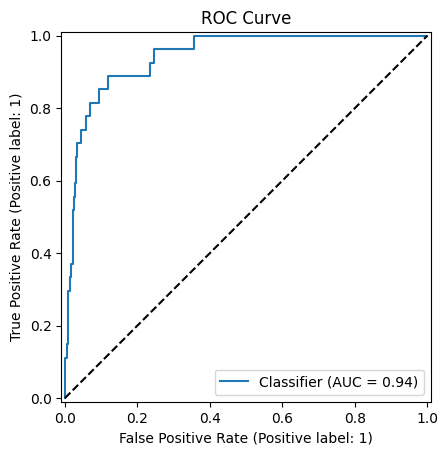

In [257]:
from sklearn.metrics import RocCurveDisplay

y_proba = rf.predict_proba(X_test)[:, 1]
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve')
plt.show()

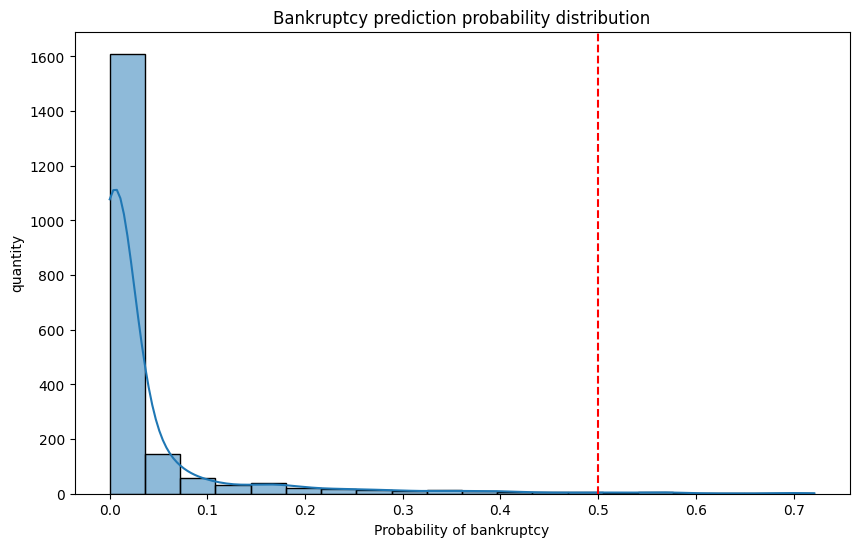

In [258]:
plt.figure(figsize=(10, 6))
sns.histplot(y_proba, bins=20, kde=True)
plt.title('Bankruptcy prediction probability distribution')
plt.xlabel('Probability of bankruptcy')
plt.ylabel('quantity')
plt.axvline(x=0.5, color='r', linestyle='--') # Decision threshold
plt.show()

# ROC curve total

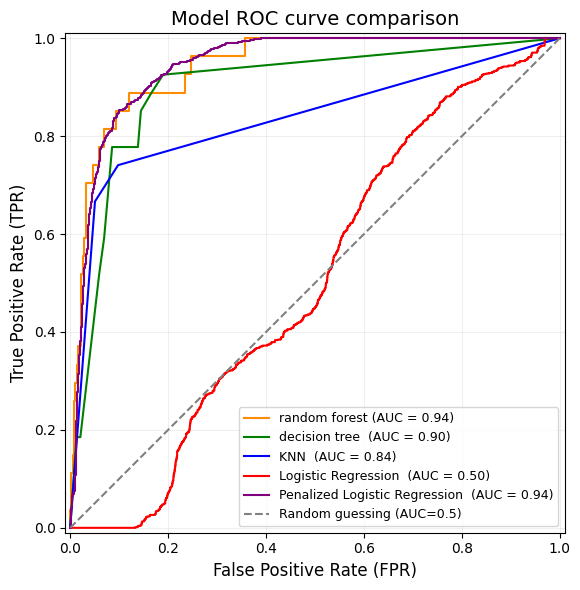

In [265]:
from sklearn.metrics import RocCurveDisplay, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np


plt.figure(figsize=(10, 6))
plt.gca().set_box_aspect(None)
# 1. Random Forest
rf_proba = rf.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_proba)
RocCurveDisplay.from_predictions(
    y_test, rf_proba,
    name=f'random forest',
    color='darkorange',
    ax=plt.gca()
)

# 2. Decision Tree
dt_proba = clf.predict_proba(X_test)[:, 1]
dt_auc = roc_auc_score(y_test, dt_proba)
RocCurveDisplay.from_predictions(
    y_test, dt_proba,
    name=f'decision tree ',
    color='green',
    ax=plt.gca()
)

# 3. KNN
knn_proba = knn.predict_proba(X_test_std)[:, 1]
knn_auc = roc_auc_score(y_test, knn_proba)
RocCurveDisplay.from_predictions(
    y_test, knn_proba,
    name=f'KNN ',
    color='blue',
    ax=plt.gca()
)

# 4. Logistic regression (two variants)
lr_proba = logreg.predict_proba(X_test_resampled)[:, 1]
lr_auc = roc_auc_score(y_test_resampled, lr_proba)
lr_proba2 = logreg2.predict_proba(scaled_X_test)[:, 1]
lr_auc2 = roc_auc_score(y_test_resampled, lr_proba2)

RocCurveDisplay.from_predictions(
    y_test_resampled, lr_proba,
    name=f'Logistic Regression ',
    color='red',
    ax=plt.gca()
)
RocCurveDisplay.from_predictions(
    y_test_resampled, lr_proba2,
    name=f'Penalized Logistic Regression ',
    color='purple',
    ax=plt.gca()
)


# Add random guides
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guessing (AUC=0.5)')
plt.title('Model ROC curve comparison', fontsize=14)
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()